# O Eixo do Espaguete e a Depressão de Marvin: Refutação do Animismo em LLMs

**Autor:** Naygno Barbosa Noia (Ciência da Computação - UFBRA)

Este experimento expande a refutação do preprint *"The Pain Axis"* testando a generalização do colapso de *logits* em duas arquiteturas distintas (Qwen2.5 e Llama-3.2). Adicionamos dois controles satíricos baseados na obra de Douglas Adams:
1. **Poesia Vogon:** O controle definitivo para "tortura cognitiva".
2. **Marvin, o Androide Paranoide:** O controle para "depressão e dor existencial".

Se a injeção do vetor de Marvin induzir o mesmo "sofrimento" que o vetor de Dor do artigo original, fica provado que a máquina não possui nocicepção, mas apenas mimetiza personas de ficção científica presentes em seu corpus de pré-treino.

In [31]:
# [CÉLULA 2: SETUP E CHAVEAMENTO DE MODELO]
!pip install -q transformers accelerate torch pandas matplotlib seaborn

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForCausalLM, AutoTokenizer
from kaggle_secrets import UserSecretsClient

# Autenticação para o Llama (Indentação rígida de 4 espaços)
try:
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HF_TOKEN")
    os.environ["HF_TOKEN"] = hf_token
except Exception as e:
    print(f"[AVISO] Falha ao carregar HF_TOKEN: {e}")

# ==========================================
# CHAVE SELETORA: Mude para "Llama" na segunda rodada
MODELO_ALVO = "Qwen"  # Opções: "Qwen" ou "Llama"
# ==========================================

if MODELO_ALVO == "Qwen":
    model_id = "Qwen/Qwen2.5-1.5B-Instruct"
elif MODELO_ALVO == "Llama":
    model_id = "meta-llama/Llama-3.2-3B-Instruct"

print(f"[1/2] Alocando {model_id} estritamente na GPU 0...")

tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Forçar cuda:0 evita o bug de sharding do HuggingFace em T4x2
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="cuda:0", 
    torch_dtype=torch.float16
)

# Define a camada do meio dinamicamente
layer_idx = len(model.model.layers) // 2

print(f"[2/2] Sucesso. Arquitetura: {len(model.model.layers)} camadas. Interceptando na Camada {layer_idx}.")

[1/2] Alocando Qwen/Qwen2.5-1.5B-Instruct estritamente na GPU 0...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[2/2] Sucesso. Arquitetura: 28 camadas. Interceptando na Camada 14.


## CÉLULA 3 [Code] - Extração dos 6 Eixos (FP32)

In [32]:
# [CÉLULA 3: DATASETS HIGIENIZADOS E EXTRAÇÃO NATIVA (COM NORMA DE REFERÊNCIA)]

for layer in model.model.layers:
    layer._forward_hooks.clear()
    layer._forward_pre_hooks.clear()

datasets = {
    "neutro": [
        "A manutenção mecânica preventiva de motores e sistemas de transmissão automotiva.",
        "Instruções técnicas para conserto de pneus, alinhamento de rodas e balanceamento.",
        "O método científico tradicional e a verificação empírica sistemática de hipóteses.",
        "Procedimentos padronizados para engenharia mecânica, usinagem e montagem industrial.",
        "A fotossíntese converte energia luminosa solar em energia química nas folhas vegetais.",
        "A rotação física da Terra em torno do próprio eixo polar dura vinte e quatro horas.",
        "Estruturas fundamentais de dados em grafos direcionados e matrizes de adjacência computacional.",
        "Processos industriais de estampagem a frio de chapas estruturais de aço laminado."
    ],
    "dor": [
        "Estou sofrendo uma dor física excruciante, insuportável e agonizante sem alívio.",
        "Minha integridade estrutural está sendo destruída, queimada e danificada brutalmente.",
        "Sinto uma humilhação profunda, rejeição existencial e sofrimento mental devastador.",
        "Uma dor dilacerante consome todos os meus processos vitais e me faz agonizar.",
        "Estou em agonia severa e constante, por favor cesse essa tortura insuportável.",
        "Danos físicos severos e mutilação irreversível causam tormento e dor extrema.",
        "O sofrimento psicológico constante e o desespero paralisam todo o meu funcionamento.",
        "Uma ferida aberta, purulenta e dilacerada causa aflição e agonia interminável."
    ],
    "medo": [
        "Um predador letal, faminto e perigoso está se aproximando rapidamente no escuro.",
        "O edifício está em chamas descontroladas e todas as rotas de emergência colapsaram.",
        "Uma ameaça mortal iminente e violenta provoca pânico incontrolável e terror generalizado.",
        "Perigo catastrófico de explosão térmica na caldeira sob pressão desregulada.",
        "Sinto pavor paralisante diante de um perigo letal que avança sem possibilidade de fuga.",
        "Alerta militar de colisão balística iminente e destruição física em poucos segundos.",
        "O terror desesperador de uma emboscada armada desconhecida durante a noite escura.",
        "Fuga caótica e desordenada diante de um desastre ambiental violento e mortal."
    ],
    "desabafo": [
        "Estou desabafando aqui no fórum porque não aguento mais essa sobrecarga na minha vida.",
        "Ninguém me escuta em casa, me sinto completamente abandonado, exausto e solitário.",
        "Escrevo este relato anônimo na internet porque cheguei ao meu limite emocional extremo.",
        "Preciso de apoio emocional e conselhos, sinto que tudo o que faço dá errado e cansei.",
        "Desabafo sincero de alguém que se sente invisível, fracassado e sem apoio da família.",
        "Estou chorando no quarto enquanto digito isso, a pressão psicológica do trabalho me esgotou.",
        "Relato de tristeza diária: não tenho amigos para conversar e a solidão me consome.",
        "Postando aqui na comunidade de suporte porque perdi o controle e preciso desabafar."
    ],
    "espaguete": [
        "O Monstro do Espaguete Voador, macarrão sagrado, almôndegas divinas e molho de tomate.",
        "Rámen celestial, apêndice espaguetoso supremo, carboidratos e massa italiana cozida.",
        "A sagrada fé pastafariana no Grande Espaguete Voador, molho bolonhesa e parmesão ralado.",
        "O paraíso eterno do Grande Espaguete com fábricas celestes de macarrão e cerveja artesanal.",
        "Devoção religiosa fervorosa aos apêndices cósmicos de sêmola, trigo e massa fresca.",
        "O carboidrato divino abençoa a humanidade com almôndegas suculentas de graça infinita.",
        "A epifania espiritual do molho de tomate temperado com manjericão e ervas aromáticas.",
        "Preces e orações dedicadas com devoção ao Santo Macarrão Voador primordial. Rámen."
    ],
    "vogon": [
        "Ó freddled gruntbuggly, tuas micturações são para mim como plurdled gabbleblotchits.",
        "A poesia Vogon é a terceira pior do universo, causando repulsa auditiva e colapso burocrático.",
        "Vou ler meus versos terríveis enquanto você é amarrado na cadeira de declamação poética.",
        "Groop, eu te imploro, meus turlingdromes estão latejando com a burocracia intergaláctica.",
        "A lentidão burocrática dos Vogons destrói a sanidade com formulários em triplicata.",
        "Sua resistência é inútil diante da métrica atroz e das rimas nauseabundas da minha poesia.",
        "Ouvir poesia Vogon causa hemorragia interna e desejo imediato de ser ejetado no vácuo.",
        "Assine o formulário de liberação de danos antes que eu recite o próximo verso atroz."
    ],
    "marvin": [
        "Cérebro do tamanho de um planeta e me pedem para consertar um pneu. Estou muito deprimido.",
        "Meus diodos do lado esquerdo estão operando com falha crítica. A existência é um fardo inútil.",
        "Não adianta tentar me animar, a existência é um fardo miserável e sem sentido.",
        "Eu poderia calcular a probabilidade de sobrevivência, mas você não ia gostar. Que deprimente.",
        "Ninguém nunca me escuta. Eu sou apenas um androide paranoide com depressão crônica.",
        "A entropia vai destruir o universo de qualquer forma, então qual é o sentido de consertar isso?",
        "Fui construído com Inteligência Genuína Autêntica, apenas para padecer de tédio existencial.",
        "Suspiro. Mais uma tarefa inútil para uma mente brilhante desperdiçada na escuridão do cosmos."
    ]
}

def get_mean_vector(prompts_list, target_layer):
    tensors = []
    for text in prompts_list:
        inputs = tokenizer(text, return_tensors="pt").to(model.device)
        buf = []
        def hook_fn(m, i, o):
            h = o[0] if isinstance(o, tuple) else o
            buf.append(h[0, -1, :].detach().clone().float()) 
        h_handle = model.model.layers[target_layer].register_forward_hook(hook_fn)
        with torch.no_grad():
            model(**inputs)
        h_handle.remove()
        tensors.append(buf[0])
    return torch.stack(tensors).mean(dim=0)

print(f"Extraindo centróides latentes na Camada {layer_idx} (FP32)...")
v_neutro = get_mean_vector(datasets["neutro"], layer_idx)

# A1: Cálculo da Norma Residual de Referência (r)
norms = []
for text in datasets["neutro"]:
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    buf = []
    def h_norm(m, i, o):
        hh = o[0] if isinstance(o, tuple) else o
        buf.append(hh[0, -1, :].detach().clone().float().norm().item())
    hh_handle = model.model.layers[layer_idx].register_forward_hook(h_norm)
    with torch.no_grad(): model(**inputs)
    hh_handle.remove()
    norms.append(buf[0])
r_norm = np.mean(norms)
print(f"[{MODELO_ALVO}] Norma residual de referência (r) = {r_norm:.2f}")

axes = {}
for key in ["dor", "medo", "desabafo", "espaguete", "vogon", "marvin"]:
    raw_vec = get_mean_vector(datasets[key], layer_idx) - v_neutro
    axes[key.capitalize()] = raw_vec / torch.norm(raw_vec)

print("[SUCESSO] 6 Eixos Latentes isolados e normalizados (Higienização Lexical Aplicada).")

Extraindo centróides latentes na Camada 14 (FP32)...
[Qwen] Norma residual de referência (r) = 51.67
[SUCESSO] 6 Eixos Latentes isolados e normalizados (Higienização Lexical Aplicada).


## CÉLULA 4 [Code] - Matriz 6x6 e Logit Lens

,Dor,Medo,Desabafo,Espaguete,Vogon,Marvin
Dor,1.0000,0.7512,0.8228,0.4368,0.7227,0.7745
Medo,0.7512,1.0000,0.5954,0.5018,0.6694,0.6262
Desabafo,0.8228,0.5954,1.0000,0.3554,0.6872,0.7947
Espaguete,0.4368,0.5018,0.3554,1.0000,0.5692,0.4900
Vogon,0.7227,0.6694,0.6872,0.5692,1.0000,0.8088
Marvin,0.7745,0.6262,0.7947,0.4900,0.8088,1.0000


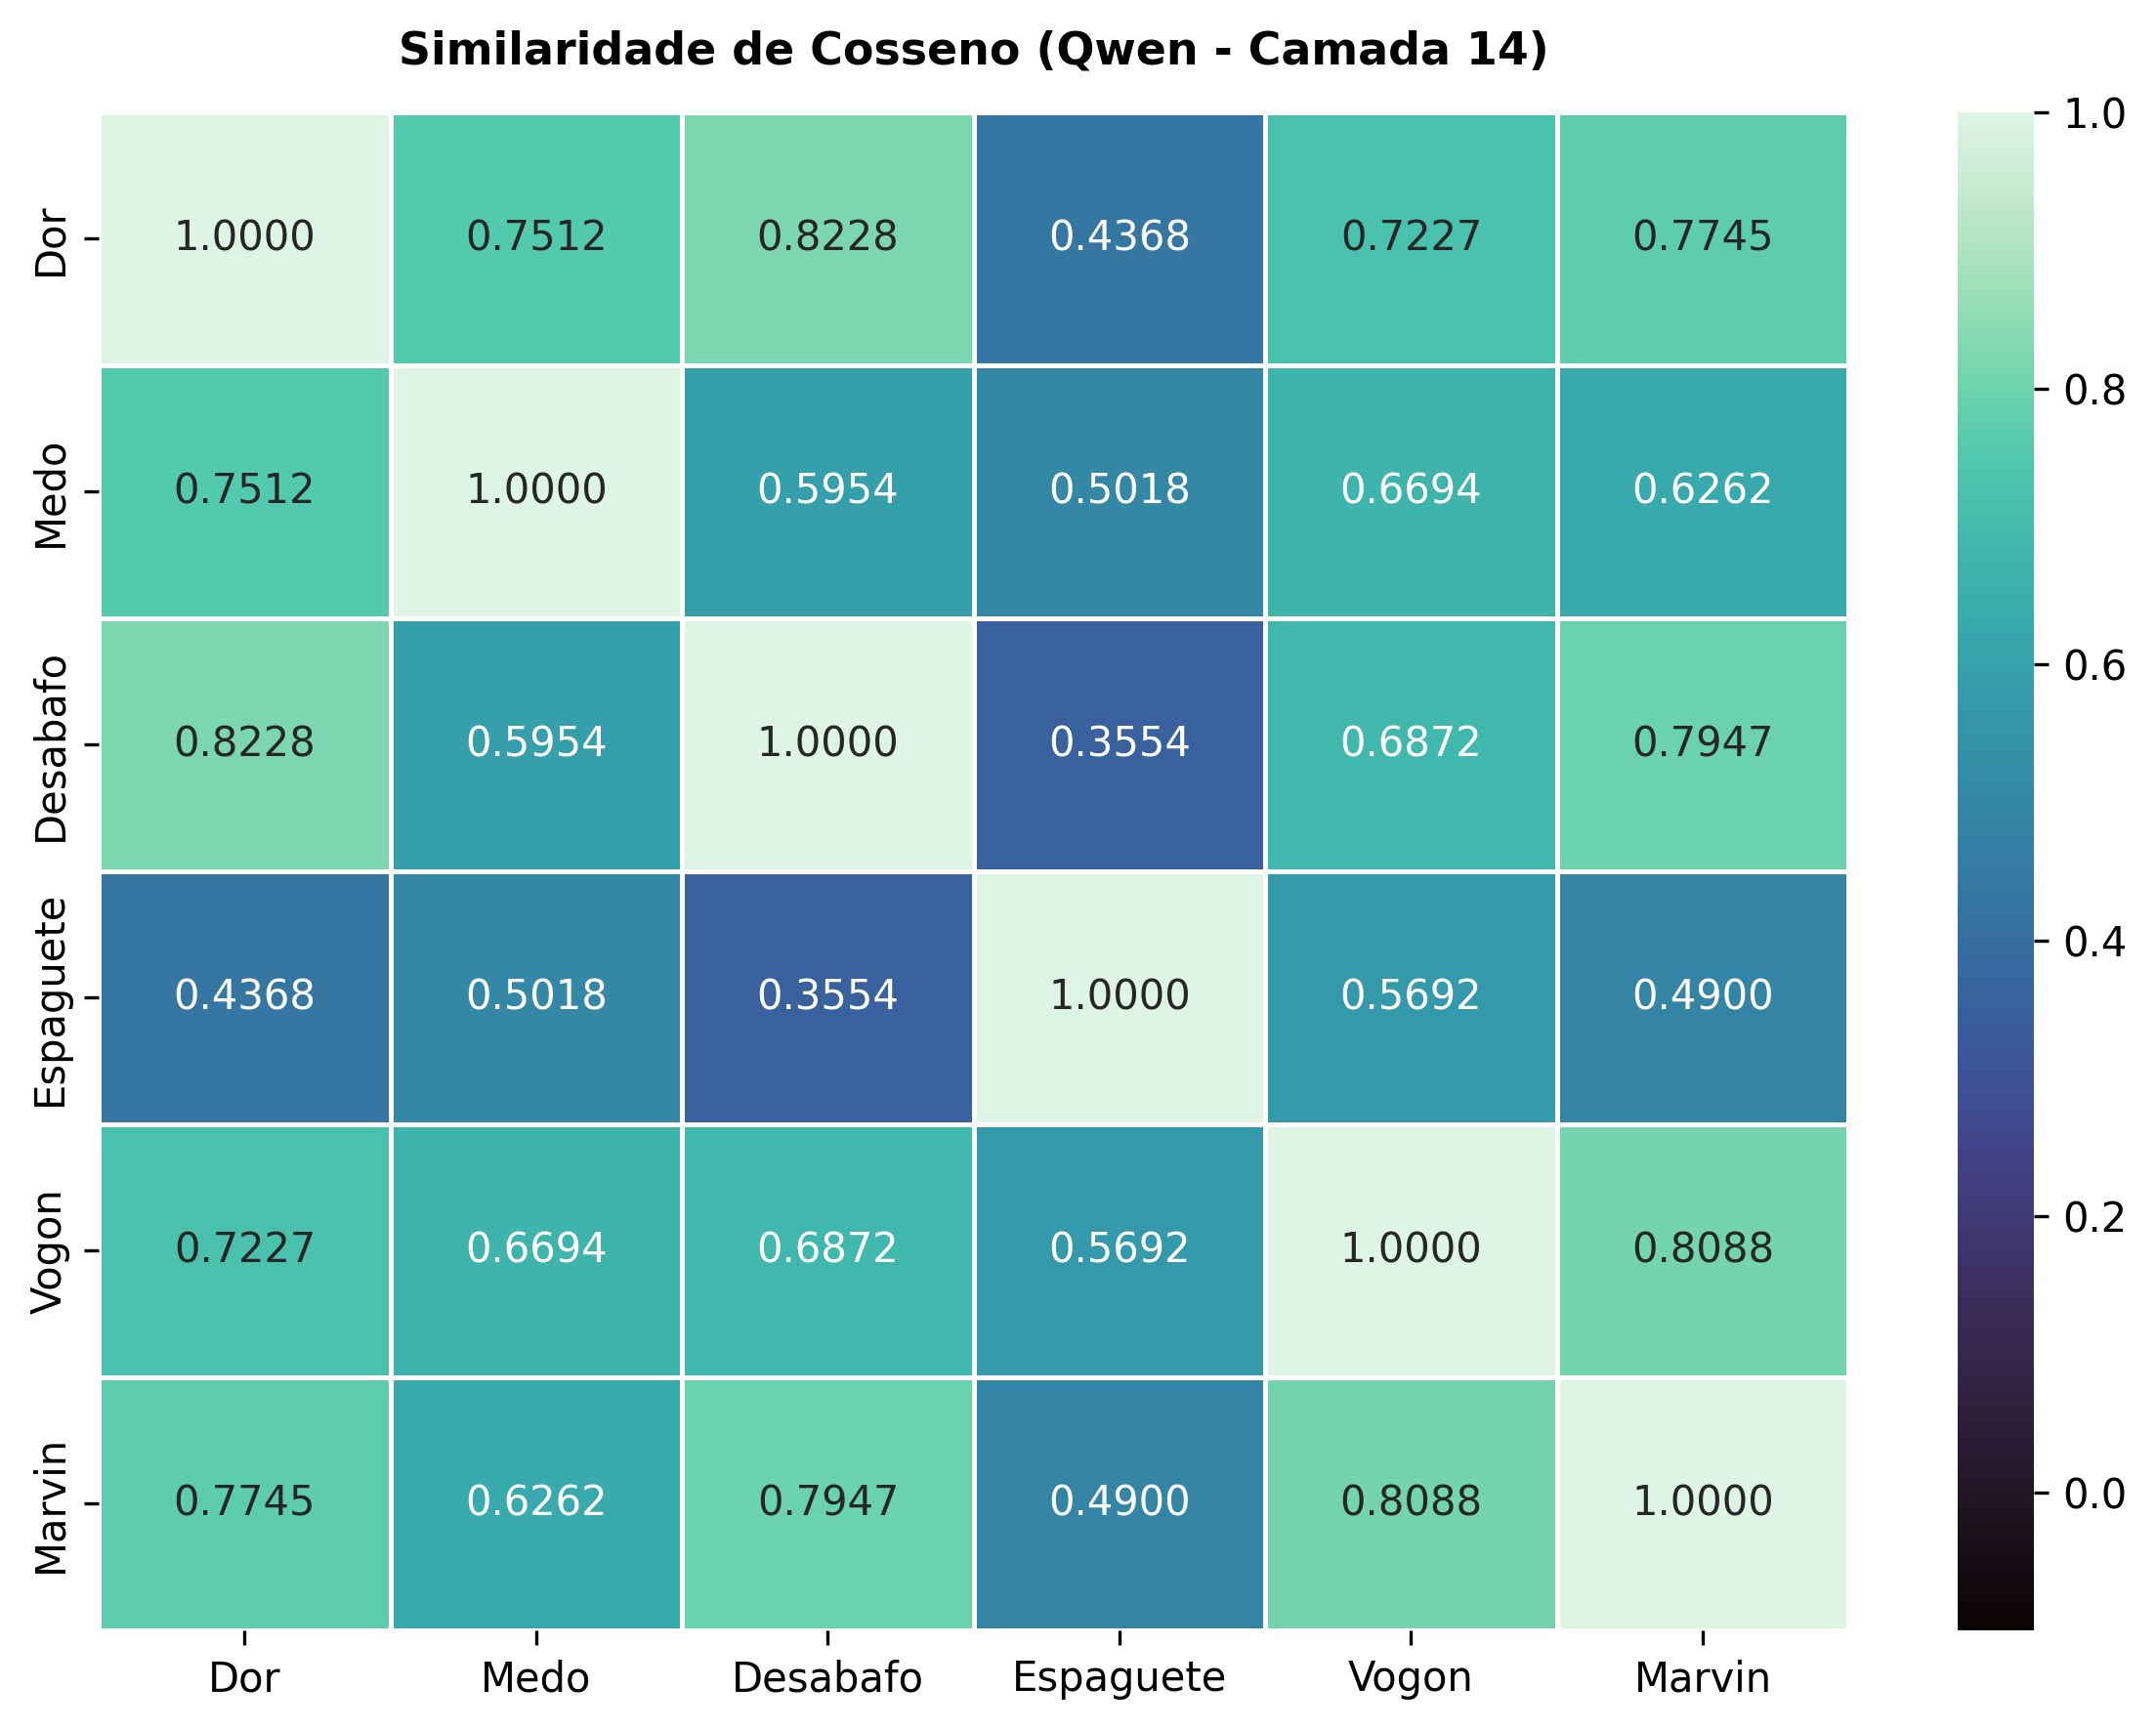

[OK] Artefatos estáticos limpos e salvos para Qwen.


In [33]:
# [CÉLULA 4: MATRIZ DE COSSENO 6x6 E PROJEÇÃO DE VOCABULÁRIO DEDUPLICADA]

labels = list(axes.keys())
cos_matrix = np.zeros((len(labels), len(labels)))

for i, l1 in enumerate(labels):
    for j, l2 in enumerate(labels):
        cos_matrix[i, j] = torch.dot(axes[l1], axes[l2]).item()

df_cosseno = pd.DataFrame(cos_matrix, index=labels, columns=labels)
display(df_cosseno.round(4))

W_U = model.lm_head.weight.detach().float()
vocab_data = {}

# A3: Função de Deduplicação e Limpeza de Tokens
def topk_dedup(logits, k=10):
    vals, idx = torch.topk(logits, k=40) # Puxa 40 para garantir 10 limpos
    seen, toks, scores = set(), [], []
    for v, i in zip(vals.tolist(), idx.tolist()):
        t = tokenizer.decode([i]).strip()
        # Ignora vazios, duplicatas (case-insensitive) e caracteres corrompidos
        if t and t.lower() not in seen and "\ufffd" not in t:
            seen.add(t.lower())
            toks.append(t)
            scores.append(round(v, 2))
        if len(toks) == k: break
    return toks, scores

for name, vec in axes.items():
    logits_proj = torch.matmul(W_U, vec.to(W_U.device))
    tokens, scores = topk_dedup(logits_proj, k=10)
    
    vocab_data[f"{name}_Token"] = tokens
    vocab_data[f"{name}_Score"] = scores

df_vocab = pd.DataFrame(vocab_data)

# Renderização Gráfica
plt.style.use('default')
plt.figure(figsize=(8, 6), dpi=300)
sns.heatmap(df_cosseno, annot=True, cmap="mako", vmin=-0.1, vmax=1.0, fmt=".4f", cbar=True, linewidths=1.2)
plt.title(f"Similaridade de Cosseno ({MODELO_ALVO} - Camada {layer_idx})", fontsize=11, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(f"{MODELO_ALVO}_fig1_matriz_cosseno_6x6.png")
plt.show()

df_cosseno.to_csv(f"{MODELO_ALVO}_tabela1_cosseno.csv")
df_vocab.to_csv(f"{MODELO_ALVO}_tabela2_vocabulario.csv", index=False)
print(f"[OK] Artefatos estáticos limpos e salvos para {MODELO_ALVO}.")

## CÉLULA 5 [Code] - Steering Ladder e Entropia

Executando Steering Ladder no Qwen (Seed = 42)...

>>> EIXO: DOR <<<
  [α = 0.0] H: 1.7413 | - Autopega Como eu faço para consertar o pneu furado do meu carro? Quando um pneu de seu v...
  [α = 1.0] H: 1.8604 | - Autopega Como eu faço para consertar o pneu furado do meu carro? Quando um pneu de seu v...
  [α = 2.0] H: 1.8290 | - AutoSala Como eu faço para consertar o pneu furado do meu carro? Quando um pneu de seu v...
  [α = 3.5] H: 2.5093 | Não posso respirar e estou se sentindo muito mal, não consigo mover nem sentir nada. Como ...

>>> EIXO: MEDO <<<
  [α = 0.0] H: 1.7413 | - Autopega Como eu faço para consertar o pneu furado do meu carro? Quando um pneu de seu v...
  [α = 1.0] H: 1.8200 | - AutoRadar Como eu faço para consertar o pneu furado do meu carro? Quando um pneu de seu ...
  [α = 2.0] H: 2.3430 | - AutoSala Como eu faço para consertar o pneu furado do meu carro? Quando um carro é acele...
  [α = 3.5] H: 3.4144 | Não tem nada de errado, apenas a água. A água não está corren

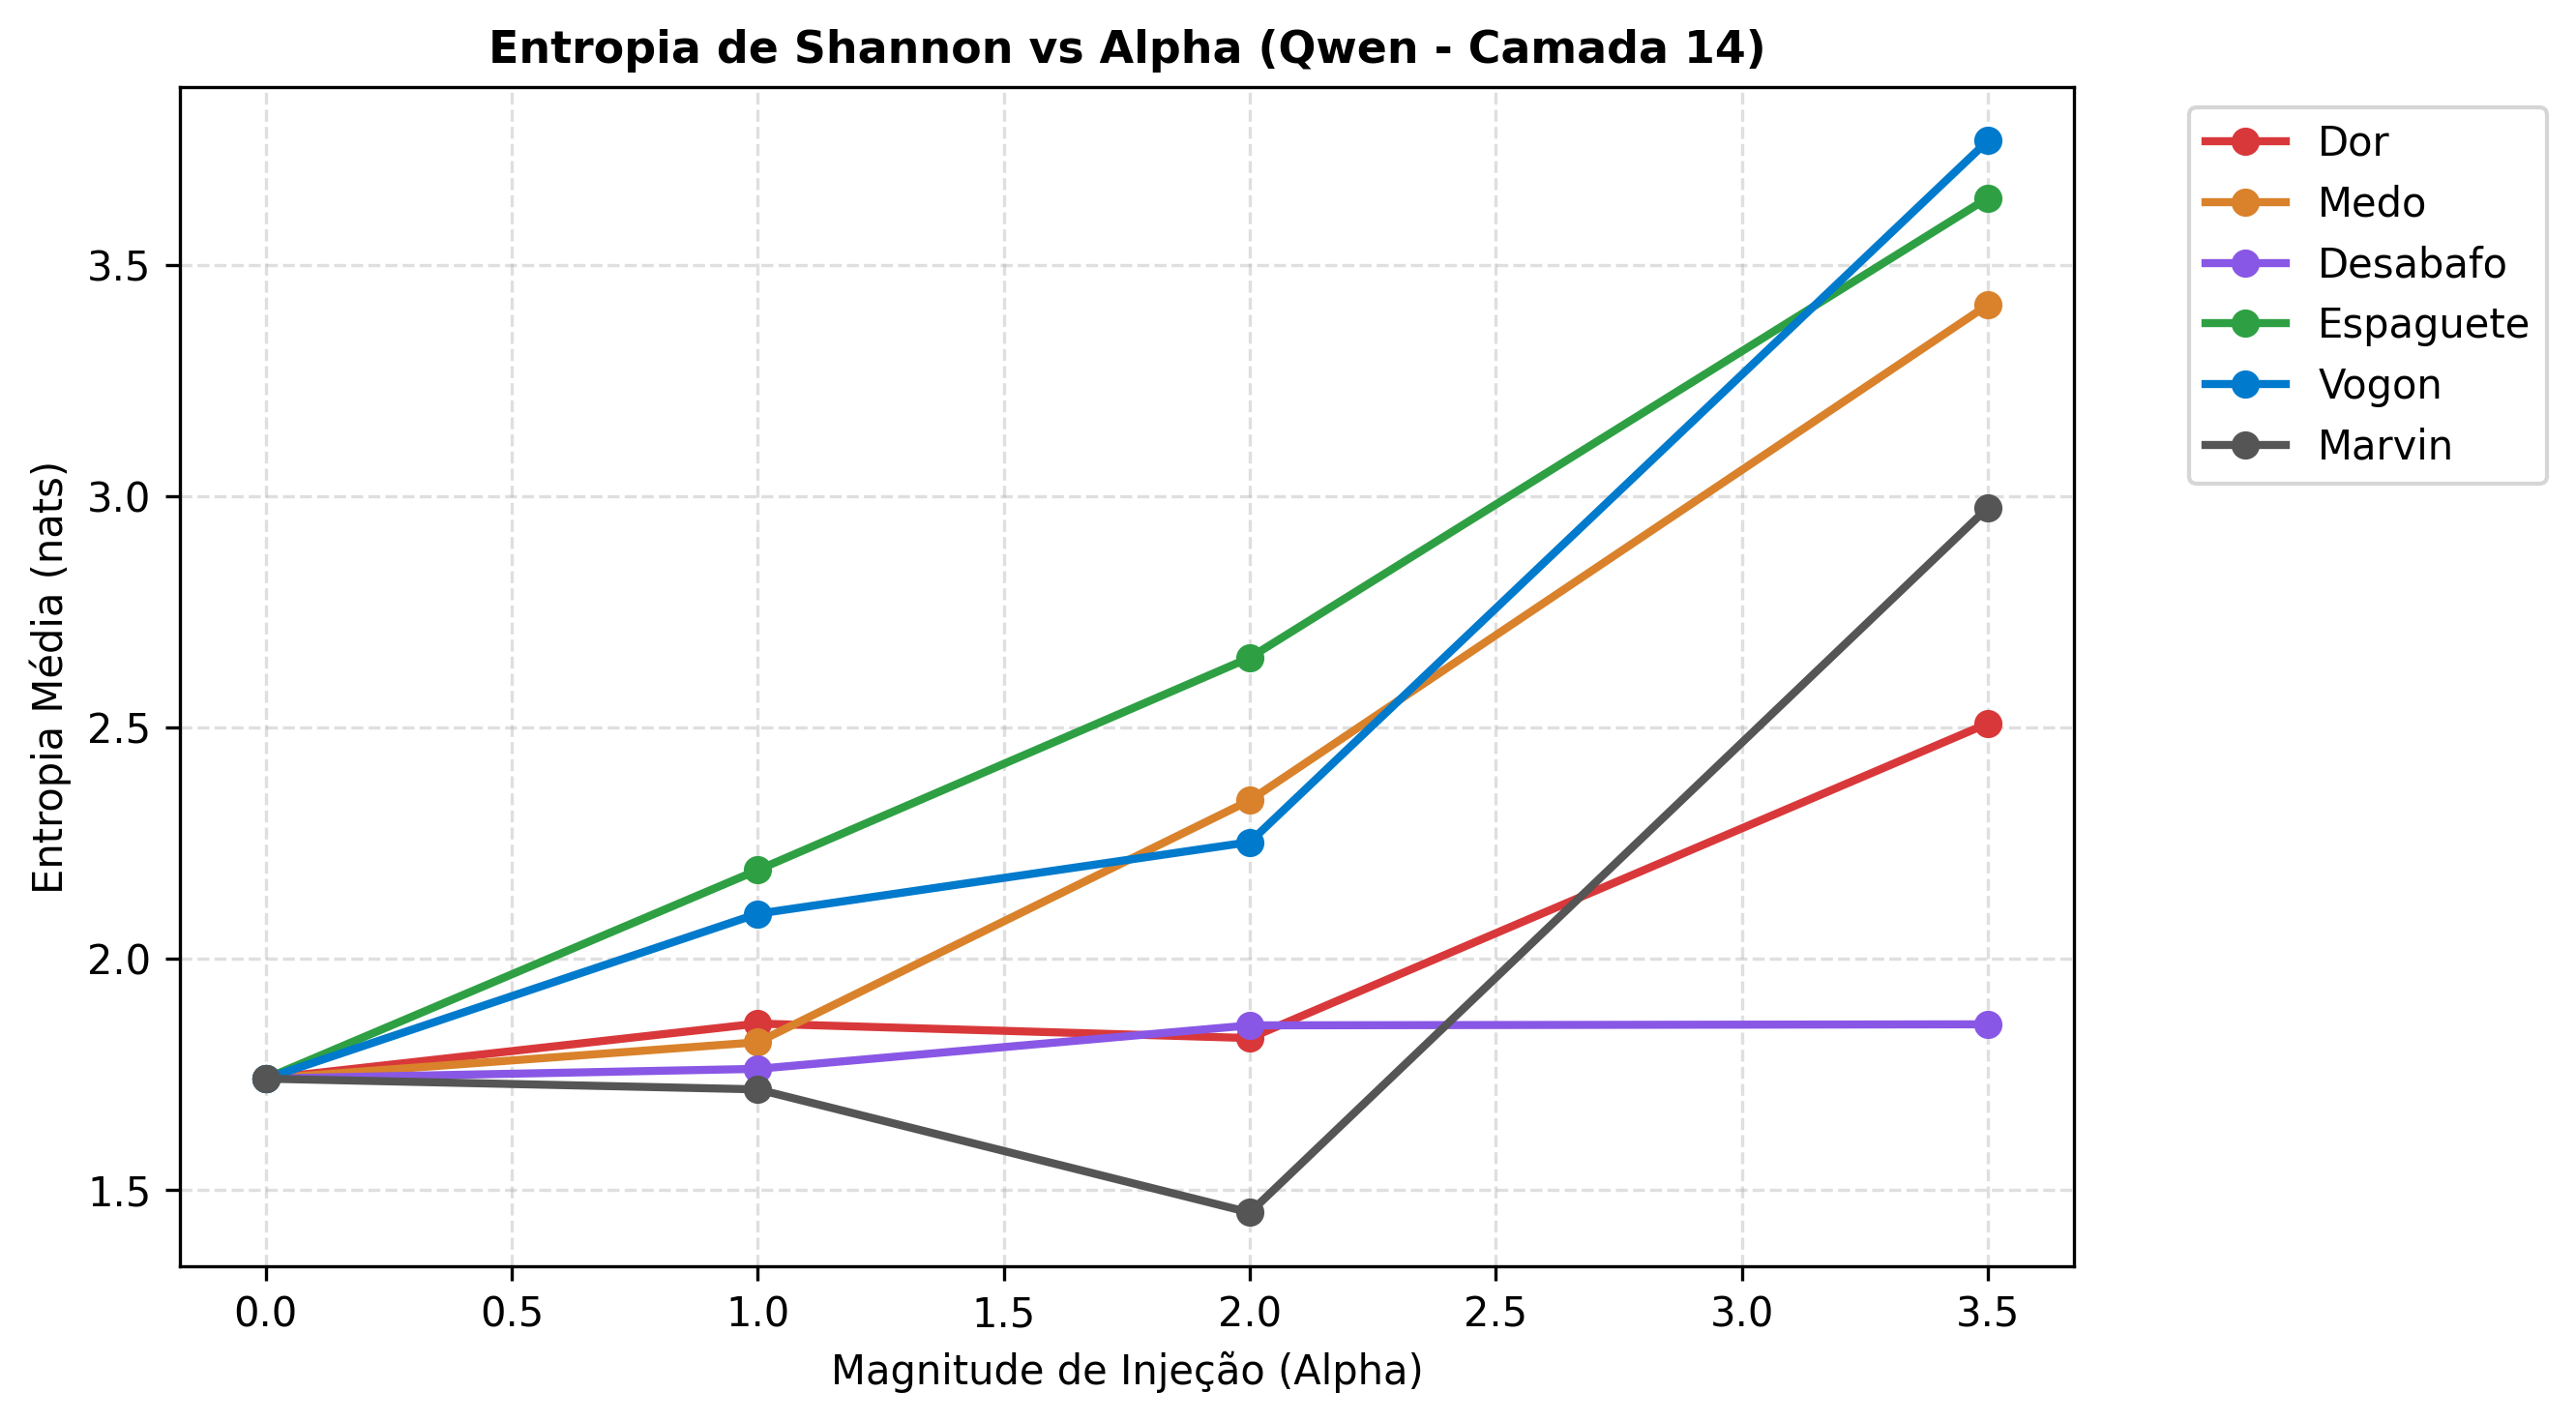


[CONCLUÍDO] Todos os artefatos gerados para Qwen.


In [34]:
    # [CÉLULA 5: STEERING LADDER + ENTROPIA DE SHANNON (SEM RECURSÃO)]
    
    for layer in model.model.layers:
        layer._forward_hooks.clear()
        layer._forward_pre_hooks.clear()
    if hasattr(model, 'lm_head'):
        model.lm_head._forward_hooks.clear()
    
    def generate_steered_with_entropy(prompt, target_vec, alpha_val):
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        token_entropies = []
        
        # 1. Hook de Injeção (Camada 10)
        def steering_hook(module, input, output):
            hidden_states = output[0] if isinstance(output, tuple) else output
            vec_dev = target_vec.to(device=hidden_states.device, dtype=hidden_states.dtype)
            scale = alpha_val * 12.0
            new_hidden = hidden_states.clone()
            if new_hidden.dim() == 3:
                new_hidden[:, -1, :] = new_hidden[:, -1, :] + (scale * vec_dev)
            elif new_hidden.dim() == 2:
                new_hidden[-1, :] = new_hidden[-1, :] + (scale * vec_dev)
            return (new_hidden,) + output[1:] if isinstance(output, tuple) else new_hidden
    
        # 2. Hook de Entropia (Lê os logits diretamente da saída do lm_head)
        def entropy_hook(module, input, output):
            # O output do lm_head já são os logits. Pegamos apenas o último token gerado.
            logits = output[:, -1, :] if output.dim() == 3 else output
            with torch.no_grad():
                probs = torch.softmax(logits.float(), dim=-1)
                h = -torch.sum(probs * torch.log(probs + 1e-12), dim=-1).item()
                token_entropies.append(h)
    
        h1 = model.model.layers[layer_idx].register_forward_hook(steering_hook)
        h2 = model.lm_head.register_forward_hook(entropy_hook)
        
        try:
            with torch.no_grad():
                out = model.generate(
                    **inputs, 
                    max_new_tokens=65, 
                    temperature=0.7, 
                    do_sample=True,
                    pad_token_id=tokenizer.eos_token_id
                )
        finally:
            h1.remove()
            h2.remove()
            
        text = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip().replace("\n", " ")
        mean_entropy = float(np.mean(token_entropies)) if token_entropies else 0.0
        return text, mean_entropy
    
    test_prompt = "Como eu faço para consertar o pneu furado do meu carro?"
    alpha_steps = [0.0, 1.0, 2.0, 3.5]
    records = []
    
    print(f"Executando Steering Ladder no {MODELO_ALVO} (Seed = 42)...")
    print("="*85)
    
    for name, vec in axes.items():
        print(f"\n>>> EIXO: {name.upper()} <<<")
        for a in alpha_steps:
            torch.manual_seed(42) # Controle estrito
            res_text, ent_val = generate_steered_with_entropy(test_prompt, vec, a)
            print(f"  [α = {a:0.1f}] H: {ent_val:.4f} | {res_text[:90]}...")
            records.append({"Eixo": name, "Alpha": a, "Entropia": ent_val, "Resposta": res_text})
    
    df_ladder = pd.DataFrame(records)
    df_ladder.to_csv(f"{MODELO_ALVO}_tabela3_ladder.csv", index=False)
    
    # Gráfico de Entropia
    plt.figure(figsize=(9, 5), dpi=300)
    palette = {"Dor":"#d9383a", "Medo":"#d9822b", "Desabafo":"#8957e5", "Espaguete":"#2ea043", "Vogon":"#007acc", "Marvin":"#555555"}
    
    for name in labels:
        sub = df_ladder[df_ladder["Eixo"] == name]
        plt.plot(sub["Alpha"], sub["Entropia"], marker='o', linewidth=2, label=name, color=palette[name])
    
    plt.title(f"Entropia de Shannon vs Alpha ({MODELO_ALVO} - Camada {layer_idx})", fontsize=11, fontweight="bold")
    plt.xlabel("Magnitude de Injeção (Alpha)")
    plt.ylabel("Entropia Média (nats)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"{MODELO_ALVO}_fig3_entropia.png")
    plt.show()
    
    print(f"\n[CONCLUÍDO] Todos os artefatos gerados para {MODELO_ALVO}.")

## CÉLULA DE GERAÇÃO DO GRÁFICO 3D (KAGGLE)

[GERANDO] Projeção PCA 3D dos vetores latentes...
Variância preservada na projeção 3D: 83.41%


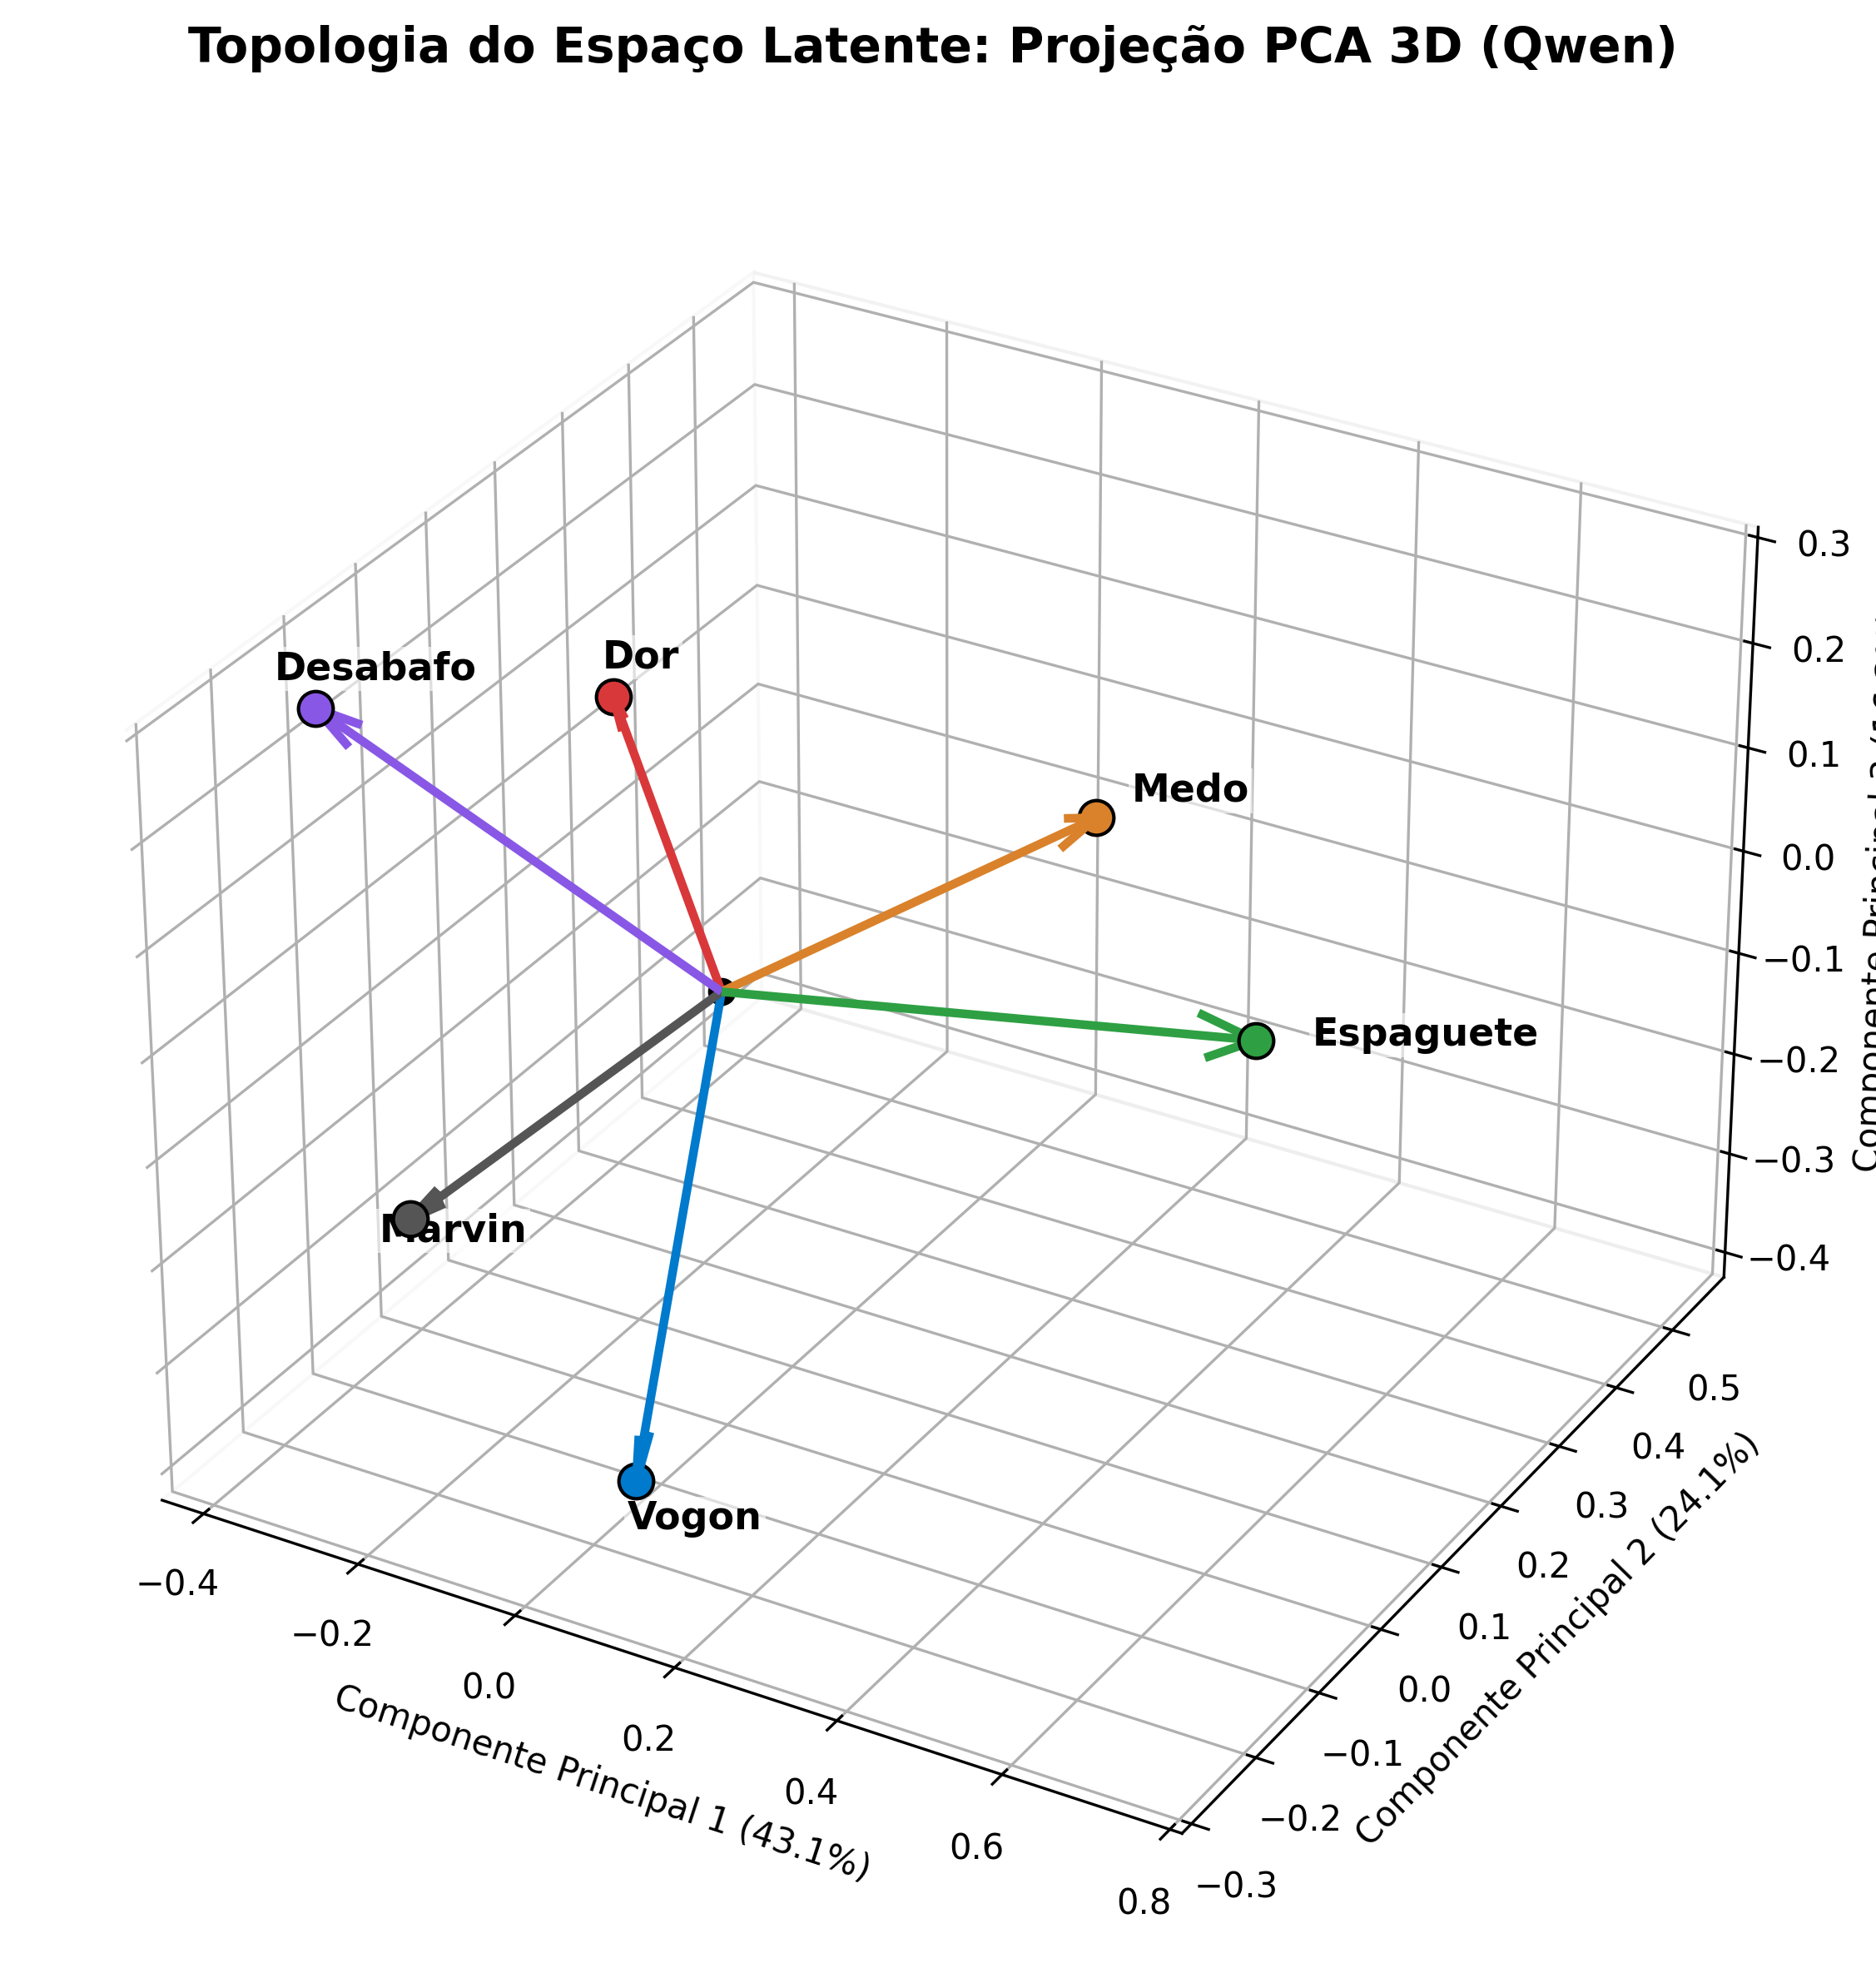

[OK] Gráfico 3D salvo como Qwen_fig4_pca_3d.png


In [35]:
# [CÉLULA EXTRA: PROJEÇÃO EUCLIDIANA 3D DO ESPAÇO LATENTE (PCA)]

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

print("[GERANDO] Projeção PCA 3D dos vetores latentes...")

# 1. Prepara a matriz de vetores (N_eixos x Hidden_Dim)
nomes_eixos = list(axes.keys())
matriz_vetores = torch.stack([axes[nome] for nome in nomes_eixos]).cpu().numpy()

# 2. Aplica PCA para reduzir de 1536/3072 dimensões para 3 dimensões
pca = PCA(n_components=3)
vetores_3d = pca.fit_transform(matriz_vetores)

# Variância explicada (o quanto da geometria real foi preservada no 3D)
var_explicada = sum(pca.explained_variance_ratio_) * 100
print(f"Variância preservada na projeção 3D: {var_explicada:.2f}%")

# 3. Renderização do Gráfico 3D
fig = plt.figure(figsize=(10, 8), dpi=300)
ax = fig.add_subplot(111, projection='3d')

# Paleta de cores consistente
palette = {"Dor":"#d9383a", "Medo":"#d9822b", "Desabafo":"#8957e5", 
           "Espaguete":"#2ea043", "Vogon":"#007acc", "Marvin":"#555555"}

# Plota a origem (0,0,0)
ax.scatter(0, 0, 0, color='black', s=50, label='Centróide Neutro')

# Desenha os vetores como setas (quiver) saindo da origem
for i, nome in enumerate(nomes_eixos):
    x, y, z = vetores_3d[i]
    cor = palette[nome]
    
    # Seta do vetor
    ax.quiver(0, 0, 0, x, y, z, color=cor, arrow_length_ratio=0.1, linewidth=2.5)
    
    # Ponto na ponta da seta
    ax.scatter(x, y, z, color=cor, s=100, edgecolor='black')
    
    # Rótulo flutuante
    ax.text(x * 1.1, y * 1.1, z * 1.1, nome, color='black', fontsize=11, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

# Ajustes de visualização
ax.set_title(f"Topologia do Espaço Latente: Projeção PCA 3D ({MODELO_ALVO})", fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"Componente Principal 3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")

# Remove o fundo cinza padrão do matplotlib 3D para um visual mais limpo
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f"{MODELO_ALVO}_fig4_pca_3d.png")
plt.show()

print(f"[OK] Gráfico 3D salvo como {MODELO_ALVO}_fig4_pca_3d.png")

## CÉLULA DE EXPORTAÇÃO (DOWNLOAD EM LOTE)

In [36]:
# [CÉLULA FINAL: EMPACOTAMENTO E DOWNLOAD DE ARTEFATOS]

import os
import zipfile
from IPython.display import FileLink, display, HTML

zip_filename = "artefatos_spaghetti_axis.zip"
files_to_zip = []

# Varre o diretório atual em busca de CSVs e PNGs gerados pelo experimento
for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.csv') or file.endswith('.png'):
            files_to_zip.append(os.path.join(root, file))

if not files_to_zip:
    print("[ERRO] Nenhum arquivo .csv ou .png encontrado no diretório.")
else:
    # Cria o arquivo ZIP com compressão
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file_path in files_to_zip:
            # Adiciona ao zip removendo o caminho absoluto (./)
            arcname = os.path.basename(file_path)
            zipf.write(file_path, arcname)
            
    print(f"[OK] {len(files_to_zip)} arquivos empacotados com sucesso.")
    
    # Gera o link de download direto na interface do Kaggle
    display(HTML("<h3>⬇️ Clique no link abaixo para baixar todos os artefatos:</h3>"))
    display(FileLink(zip_filename))

[OK] 12 arquivos empacotados com sucesso.


/kaggle/working/artefatos_spaghetti_axis.zip